### EchoNet-Dynamic Feature Extraction for Cardiac 3D Modelling

This notebook extracts functional and geometric features from the EchoNet-Dynamic dataset for use in a 3D heart deformation pipeline. The goal is to convert 2D echocardiographic information into a structured parameter space that can later guide 3D visualization of cardiac behaviour.

The extracted features include:
- Functional metrics: ejection fraction (EF), end-diastolic volume (EDV), and end-systolic volume (ESV)
- Geometric metrics: left ventricle (LV) area, width, height, and sphericity at end-diastole and end-systole
- Derived categories: EF category and LV size category

### Objective

The main objective of this notebook is to transform raw EchoNet-Dynamic data into a clean, validated dataset of functional and geometric cardiac features.

This notebook specifically aims to:
1. Load and inspect the EchoNet-Dynamic metadata and tracing files
2. Extract core functional measurements from `FileList.csv`
3. Reconstruct LV boundary information from `VolumeTracings.csv`
4. Compute LV area for traced frames using a convex hull approach
5. Identify end-diastolic (ED) and end-systolic (ES) frames
6. Derive shape descriptors such as width, height, and sphericity
7. Combine all extracted features into a final structured dataset
8. Validate the extracted features using physiological consistency checks

### Importing Required Libraries

The following libraries are used in this notebook:

- `pandas` for data loading and tabular manipulation
- `numpy` for numerical operations
- `matplotlib` for visualization
- `scipy.spatial.ConvexHull` for stable area computation from LV contour points

These tools are sufficient to preprocess the dataset, compute features, and validate the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Loading the Dataset Files

The EchoNet-Dynamic dataset contains two main CSV files used in this notebook:

- `FileList.csv`: contains case-level metadata and functional measurements such as EF, EDV, and ESV
- `VolumeTracings.csv`: contains LV tracing coordinates for selected frames

These files are loaded into pandas DataFrames for further analysis.

In [2]:
filelist = pd.read_csv("C:\\Users\\ACER\\Downloads\\EchoNet-Dynamic\\EchoNet-Dynamic\\FileList.csv")
tracings = pd.read_csv("C:\\Users\\ACER\\Downloads\\EchoNet-Dynamic\\EchoNet-Dynamic\\VolumeTracings.csv")

print(filelist.head())
print(tracings.head())

             FileName         EF         ESV         EDV  FrameHeight  \
0  0X100009310A3BD7FC  78.498406   14.881368   69.210534          112   
1  0X1002E8FBACD08477  59.101988   40.383876   98.742884          112   
2  0X1005D03EED19C65B  62.363798   14.267784   37.909734          112   
3  0X10075961BC11C88E  54.545097   33.143084   72.914210          112   
4  0X10094BA0A028EAC3  24.887742  127.581945  169.855024          112   

   FrameWidth  FPS  NumberOfFrames  Split  
0         112   50             174    VAL  
1         112   50             215  TRAIN  
2         112   50             104  TRAIN  
3         112   55             122  TRAIN  
4         112   52             207    VAL  
                 FileName         X1         Y1         X2         Y2  Frame
0  0X100009310A3BD7FC.avi  51.260417  15.348958  64.932292  69.125000     46
1  0X100009310A3BD7FC.avi  50.037611  17.167841  53.367222  16.321330     46
2  0X100009310A3BD7FC.avi  49.157378  20.407629  57.090549  18.390

FileList.csv file consists of:
- `FileName`
- `EF` (ejection fraction)
- `EDV` (end-diastolic volume)
- `ESV` (end-systolic volume)
- additional metadata such as frame size and split


In [3]:
print(filelist.columns)

Index(['FileName', 'EF', 'ESV', 'EDV', 'FrameHeight', 'FrameWidth', 'FPS',
       'NumberOfFrames', 'Split'],
      dtype='object')


VolumeTracings.csv file consists of:
- `FileName`
- paired tracing coordinates: `X1`, `Y1`, `X2`, `Y2`
- `Frame`

These tracing points describe the LV boundary in selected frames and are used to derive geometric features.

In [4]:
print(tracings.columns)

Index(['FileName', 'X1', 'Y1', 'X2', 'Y2', 'Frame'], dtype='object')


#### Aligning File Names Across Data Sources

Before merging data from the two files, the `FileName` format must be made consistent.

A mismatch exists because:
- `FileList.csv` stores file names without the `.avi` extension
- `VolumeTracings.csv` stores file names with the `.avi` extension

To ensure a correct merge, the file names are standardized by appending `.avi` to the entries in `FileList.csv`. 

During preprocessing, a file name mismatch issue was identified due to repeated appending of the `.avi` extension. This was corrected before merging to ensure that each case in `FileList.csv` matches the corresponding tracing entries in `VolumeTracings.csv`.

In [5]:
filelist["FileName"] = filelist["FileName"] + ".avi"

### Extracting Functional Features

The first set of features extracted are the core functional cardiac measurements:

- `EF`: ejection fraction, indicating pumping efficiency
- `EDV`: end-diastolic volume, representing the volume of blood in the ventricle before contraction
- `ESV`: end-systolic volume, representing the remaining blood volume after contraction

These variables provide the functional basis of the later 3D deformation pipeline.

In [6]:
features = filelist[["FileName", "EF", "EDV", "ESV"]].copy()

print(features.head())

                 FileName         EF         EDV         ESV
0  0X100009310A3BD7FC.avi  78.498406   69.210534   14.881368
1  0X1002E8FBACD08477.avi  59.101988   98.742884   40.383876
2  0X1005D03EED19C65B.avi  62.363798   37.909734   14.267784
3  0X10075961BC11C88E.avi  54.545097   72.914210   33.143084
4  0X10094BA0A028EAC3.avi  24.887742  169.855024  127.581945


###  LV Tracings

To better understand how the left ventricle (LV) is represented in the dataset, we first extract the tracing points for a single sample case and a single frame.

The tracing data contains paired coordinates (X1, Y1) and (X2, Y2), which together represent sampled points along the LV boundary. However, these points are not stored in a strictly ordered sequence, so directly connecting them as lines may produce incorrect shapes.

To avoid this issue, the points are first visualized using a scatter plot. This allows us to observe the spatial distribution of the LV boundary without introducing artificial connections.

The Y-axis is inverted to match the coordinate system typically used in image data, where the origin is located at the top-left.

This step helps verify that the tracing points form a meaningful anatomical shape before proceeding to area and shape comp. ations

This helps confirm that the tracing points capture the expected LV shape.

In [7]:
def build_contour(df):
    # combine all points
    x = np.concatenate([df["X1"].values, df["X2"].values])
    y = np.concatenate([df["Y1"].values, df["Y2"].values])
    
    return x, y

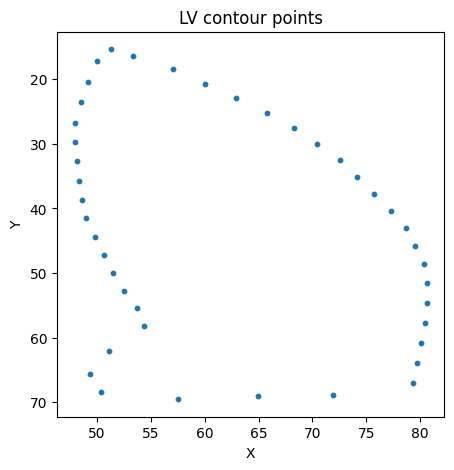

In [8]:
sample_df = tracings[
    (tracings["FileName"] == tracings["FileName"].iloc[0]) &
    (tracings["Frame"] == tracings["Frame"].iloc[0])
]
x, y = build_contour(sample_df)
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

# scatter points (better for this case)
plt.scatter(x, y, s=10)

plt.gca().invert_yaxis()
plt.title("LV contour points")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()




The scatter pl aboveot shows that the tracing points form a closed boundary representing the left ventricle.

Although the points are not explicitly ordered, their spatial arrangement clearly outlines the LV shape. This confirms that the dataset provides sufficient geometric information to reconstruct the ventricle boundaration.

### Computing LV Area from Tracing Points

To calculate LV area from the tracing coordinates, a stable boundary representation is required.

Instead of directly joining points in sequence, a convex hull approach is used. This method constructs the outer boundary enclosing all tracing points and avoids issues caused by unordered or irregular point sequences.

The convex hull is appropriate here because the goal is to derive a robust geometric approximation of LV size for downstream feature extraction.

In [9]:
from scipy.spatial import ConvexHull

def compute_area(df):
    points = np.vstack([
        np.column_stack((df["X1"], df["Y1"])),
        np.column_stack((df["X2"], df["Y2"]))
    ])
    
    hull = ConvexHull(points)
    return hull.volume

In [10]:
areas = []

for (fname, frame), group in tracings.groupby(["FileName", "Frame"]):
    area = compute_area(group)
    
    areas.append({
        "FileName": fname,
        "Frame": frame,
        "LV_Area": area
    })

areas_df = pd.DataFrame(areas)

print(areas_df.head())

                 FileName  Frame      LV_Area
0  0X100009310A3BD7FC.avi     46  1339.845857
1  0X100009310A3BD7FC.avi     61   587.623706
2  0X1002E8FBACD08477.avi      3  1169.178824
3  0X1002E8FBACD08477.avi     18   644.021145
4  0X1005D03EED19C65B.avi     24   805.685794


### Area Computation for Each Traced Frame

For each unique combination of `FileName` and `Frame`, the LV area is computed from the tracing points using the convex hull method.

The resulting table contains:
- the case identifier
- the frame number
- the computed LV area

This provides a frame-level geometric representation of LV size.

In [11]:
ed_es = []

for fname, group in areas_df.groupby("FileName"):
    ed = group.loc[group["LV_Area"].idxmax()]
    es = group.loc[group["LV_Area"].idxmin()]
    
    ed_es.append({
        "FileName": fname,
        "ED_Frame": ed["Frame"],
        "ED_Area": ed["LV_Area"],
        "ES_Frame": es["Frame"],
        "ES_Area": es["LV_Area"]
    })

ed_es_df = pd.DataFrame(ed_es)

print(ed_es_df.head())

                 FileName  ED_Frame      ED_Area  ES_Frame      ES_Area
0  0X100009310A3BD7FC.avi        46  1339.845857        61   587.623706
1  0X1002E8FBACD08477.avi         3  1169.178824        18   644.021145
2  0X1005D03EED19C65B.avi        24   805.685794        35   456.496272
3  0X10075961BC11C88E.avi        91  1038.684449       108   658.519032
4  0X10094BA0A028EAC3.avi       137  1967.320625       156  1609.433250


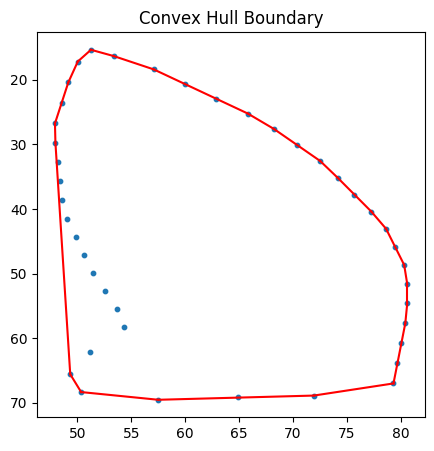

In [12]:
from scipy.spatial import ConvexHull

points = np.vstack([
    np.column_stack((sample_df["X1"], sample_df["Y1"])),
    np.column_stack((sample_df["X2"], sample_df["Y2"]))
])

hull = ConvexHull(points)

plt.figure(figsize=(5,5))
plt.scatter(points[:,0], points[:,1], s=10)

for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'r-')

plt.gca().invert_yaxis()
plt.title("Convex Hull Boundary")
plt.show()

In [13]:
print(ed_es_df.head(20))

                  FileName  ED_Frame      ED_Area  ES_Frame      ES_Area
0   0X100009310A3BD7FC.avi        46  1339.845857        61   587.623706
1   0X1002E8FBACD08477.avi         3  1169.178824        18   644.021145
2   0X1005D03EED19C65B.avi        24   805.685794        35   456.496272
3   0X10075961BC11C88E.avi        91  1038.684449       108   658.519032
4   0X10094BA0A028EAC3.avi       137  1967.320625       156  1609.433250
5   0X100CF05D141FF143.avi       132  1327.269482       148   804.556609
6   0X100E3B8D3280BEC5.avi        25  1254.398581        38   927.354547
7   0X100E491B3CD58DE2.avi        49  1303.882183        75  1021.504614
8   0X100F044876B98F90.avi        56  1209.990061        72   659.301073
9   0X101026B90DAE7E95.avi        45  1692.247816        62  1183.937367
10  0X1012703CDC1436FE.avi       154  2250.193066       172  1651.147454
11   0X1013E8A4864781B.avi        35   519.175510        46   298.888474
12  0X1018521A3BC5CDBA.avi        42  1168.913806  

In [14]:
wrong_cases = ed_es_df[ed_es_df["ED_Area"] <= ed_es_df["ES_Area"]]

print(wrong_cases)

Empty DataFrame
Columns: [FileName, ED_Frame, ED_Area, ES_Frame, ES_Area]
Index: []


In [15]:
print((ed_es_df["ED_Area"] > ed_es_df["ES_Area"]).mean())

1.0


In [16]:
print(filelist["FileName"].head())
print(ed_es_df["FileName"].head())

0    0X100009310A3BD7FC.avi
1    0X1002E8FBACD08477.avi
2    0X1005D03EED19C65B.avi
3    0X10075961BC11C88E.avi
4    0X10094BA0A028EAC3.avi
Name: FileName, dtype: object
0    0X100009310A3BD7FC.avi
1    0X1002E8FBACD08477.avi
2    0X1005D03EED19C65B.avi
3    0X10075961BC11C88E.avi
4    0X10094BA0A028EAC3.avi
Name: FileName, dtype: object


In [17]:
features = filelist[["FileName", "EF", "EDV", "ESV"]].copy()

final_df = features.merge(ed_es_df, on="FileName", how="inner")

print(final_df.head())

                 FileName         EF         EDV         ESV  ED_Frame  \
0  0X100009310A3BD7FC.avi  78.498406   69.210534   14.881368        46   
1  0X1002E8FBACD08477.avi  59.101988   98.742884   40.383876         3   
2  0X1005D03EED19C65B.avi  62.363798   37.909734   14.267784        24   
3  0X10075961BC11C88E.avi  54.545097   72.914210   33.143084        91   
4  0X10094BA0A028EAC3.avi  24.887742  169.855024  127.581945       137   

       ED_Area  ES_Frame      ES_Area  
0  1339.845857        61   587.623706  
1  1169.178824        18   644.021145  
2   805.685794        35   456.496272  
3  1038.684449       108   658.519032  
4  1967.320625       156  1609.433250  


In [18]:
print("EDV vs ED_Area:", final_df["EDV"].corr(final_df["ED_Area"]))
print("ESV vs ES_Area:", final_df["ESV"].corr(final_df["ES_Area"]))

EDV vs ED_Area: 0.3656102374870084
ESV vs ES_Area: 0.5552626672876995


In [19]:
def shape_metrics(df):
    points = np.vstack([
        np.column_stack((df["X1"], df["Y1"])),
        np.column_stack((df["X2"], df["Y2"]))
    ])
    
    x = points[:,0]
    y = points[:,1]
    
    width = x.max() - x.min()
    height = y.max() - y.min()
    
    sphericity = width / height if height != 0 else np.nan
    
    return width, height, sphericity

In [20]:
shape_rows = []

grouped = tracings.groupby(["FileName", "Frame"])
trace_dict = {k: v for k, v in grouped}

for _, row in ed_es_df.iterrows():
    ed_df = trace_dict[(row["FileName"], row["ED_Frame"])]
    es_df = trace_dict[(row["FileName"], row["ES_Frame"])]
    
    ed_w, ed_h, ed_s = shape_metrics(ed_df)
    es_w, es_h, es_s = shape_metrics(es_df)
    
    shape_rows.append({
        "FileName": row["FileName"],
        "ED_Width": ed_w,
        "ED_Height": ed_h,
        "ED_Sphericity": ed_s,
        "ES_Width": es_w,
        "ES_Height": es_h,
        "ES_Sphericity": es_s
    })

shape_df = pd.DataFrame(shape_rows)

print(shape_df.head())

                 FileName   ED_Width  ED_Height  ED_Sphericity   ES_Width  \
0  0X100009310A3BD7FC.avi  32.690407  54.206370       0.603073  17.852324   
1  0X1002E8FBACD08477.avi  35.931576  50.342220       0.713746  25.057017   
2  0X1005D03EED19C65B.avi  30.126620  45.089370       0.668153  23.026131   
3  0X10075961BC11C88E.avi  26.408998  50.519345       0.522750  21.610560   
4  0X10094BA0A028EAC3.avi  39.535994  64.687486       0.611185  35.148023   

   ES_Height  ES_Sphericity  
0  43.384486       0.411491  
1  38.627931       0.648676  
2  35.323319       0.651868  
3  43.824984       0.493111  
4  57.731203       0.608822  


In [42]:
features = filelist[["FileName", "EF", "EDV", "ESV"]].copy()

final_df = features.merge(ed_es_df, on="FileName", how="inner")
final_df = final_df.merge(shape_df, on="FileName", how="inner")

print(final_df.head())

                 FileName         EF         EDV         ESV  ED_Frame  \
0  0X100009310A3BD7FC.avi  78.498406   69.210534   14.881368        46   
1  0X1002E8FBACD08477.avi  59.101988   98.742884   40.383876         3   
2  0X1005D03EED19C65B.avi  62.363798   37.909734   14.267784        24   
3  0X10075961BC11C88E.avi  54.545097   72.914210   33.143084        91   
4  0X10094BA0A028EAC3.avi  24.887742  169.855024  127.581945       137   

       ED_Area  ES_Frame      ES_Area   ED_Width  ED_Height  ED_Sphericity  \
0  1339.845857        61   587.623706  32.690407  54.206370       0.603073   
1  1169.178824        18   644.021145  35.931576  50.342220       0.713746   
2   805.685794        35   456.496272  30.126620  45.089370       0.668153   
3  1038.684449       108   658.519032  26.408998  50.519345       0.522750   
4  1967.320625       156  1609.433250  39.535994  64.687486       0.611185   

    ES_Width  ES_Height  ES_Sphericity  
0  17.852324  43.384486       0.411491  
1  2

In [44]:
def ef_category(ef):
    if ef >= 55:
        return "normal"
    elif ef >= 41:
        return "borderline"
    else:
        return "reduced"

final_df["EF_Category"] = final_df["EF"].apply(ef_category)

In [46]:
def lv_size(edv):
    if edv < 120:
        return "normal"
    elif edv < 160:
        return "borderline"
    else:
        return "enlarged"

final_df["LV_Size_Category"] = final_df["EDV"].apply(lv_size)

In [48]:
final_df.to_csv("echonet_final_dataset.csv", index=False)

In [50]:
print((final_df["ED_Width"] > final_df["ES_Width"]).mean())
print((final_df["ED_Height"] > final_df["ES_Height"]).mean())

0.9969074221867518
0.9881284916201117


In [52]:
print((final_df["ED_Sphericity"] > final_df["ES_Sphericity"]).mean())

0.9462290502793296


In [54]:
final_df[["ED_Width", "ED_Height"]].describe()

,ED_Width,ED_Height
count,10024.000000,10024.000000
mean,35.519304,56.954551
std,7.648184,9.333891
min,12.019780,30.855682
25%,30.257829,50.479873
50%,34.692011,55.509536
75%,39.750476,62.179222
max,98.901239,112.436790


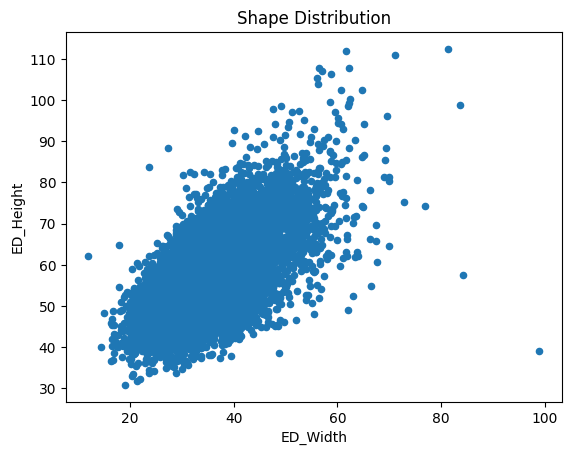

In [56]:
final_df.plot.scatter(x="ED_Width", y="ED_Height")
plt.title("Shape Distribution")
plt.show()

In [58]:
final_df = pd.read_csv("echonet_final_dataset.csv")

In [60]:
print(final_df.head())

                 FileName         EF         EDV         ESV  ED_Frame  \
0  0X100009310A3BD7FC.avi  78.498406   69.210534   14.881368        46   
1  0X1002E8FBACD08477.avi  59.101988   98.742884   40.383876         3   
2  0X1005D03EED19C65B.avi  62.363798   37.909734   14.267784        24   
3  0X10075961BC11C88E.avi  54.545097   72.914210   33.143084        91   
4  0X10094BA0A028EAC3.avi  24.887742  169.855024  127.581945       137   

       ED_Area  ES_Frame      ES_Area   ED_Width  ED_Height  ED_Sphericity  \
0  1339.845857        61   587.623706  32.690407  54.206370       0.603073   
1  1169.178824        18   644.021145  35.931576  50.342220       0.713746   
2   805.685794        35   456.496272  30.126620  45.089370       0.668153   
3  1038.684449       108   658.519032  26.408998  50.519345       0.522750   
4  1967.320625       156  1609.433250  39.535994  64.687486       0.611185   

    ES_Width  ES_Height  ES_Sphericity EF_Category LV_Size_Category  
0  17.852324  43

In [62]:
print(final_df.columns)

Index(['FileName', 'EF', 'EDV', 'ESV', 'ED_Frame', 'ED_Area', 'ES_Frame',
       'ES_Area', 'ED_Width', 'ED_Height', 'ED_Sphericity', 'ES_Width',
       'ES_Height', 'ES_Sphericity', 'EF_Category', 'LV_Size_Category'],
      dtype='object')


In [64]:
print(final_df.isna().sum())

FileName            0
EF                  0
EDV                 0
ESV                 0
ED_Frame            0
ED_Area             0
ES_Frame            0
ES_Area             0
ED_Width            0
ED_Height           0
ED_Sphericity       0
ES_Width            0
ES_Height           0
ES_Sphericity       0
EF_Category         0
LV_Size_Category    0
dtype: int64


In [66]:
print(final_df.shape)

(10024, 16)


In [68]:
print(final_df.describe())

                 EF           EDV           ESV      ED_Frame       ED_Area  \
count  10024.000000  10024.000000  10024.000000  10024.000000  10024.000000   
mean      55.747266     91.320651     43.429113     66.371907   1480.018687   
std       12.374155     45.670310     35.837632     39.783498    548.404549   
min        6.907258     12.618671      4.350710      0.000000    373.945468   
25%       51.598763     62.163521     23.680901     42.000000   1110.313086   
50%       59.207122     82.080405     33.584638     57.000000   1362.907427   
75%       63.959618    108.286229     49.109905     91.000000   1726.876105   
max       96.967237    695.036025    612.489815    664.000000   6168.655681   

           ES_Frame       ES_Area      ED_Width     ED_Height  ED_Sphericity  \
count  10024.000000  10024.000000  10024.000000  10024.000000   10024.000000   
mean      82.570630    923.454115     35.519304     56.954551       0.626481   
std       40.661641    405.878845      7.648184 

In [70]:
print((final_df["ED_Area"] > final_df["ES_Area"]).mean())

1.0


In [72]:
print((final_df["ED_Width"] > final_df["ES_Width"]).mean())

0.9969074221867518


In [74]:
print(final_df["EF_Category"].value_counts())
print(final_df["LV_Size_Category"].value_counts())

EF_Category
normal        6957
borderline    1721
reduced       1346
Name: count, dtype: int64
LV_Size_Category
normal        8198
borderline    1149
enlarged       677
Name: count, dtype: int64


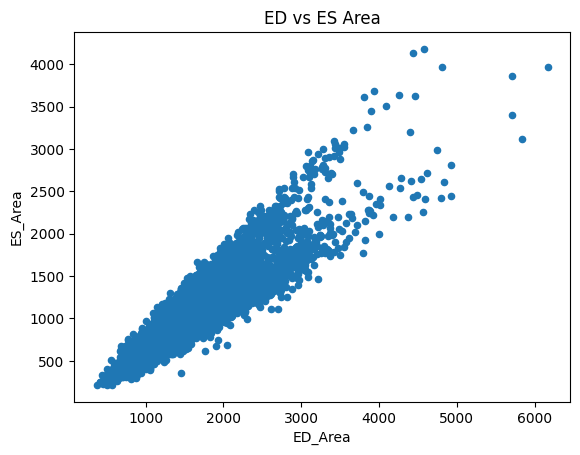

In [76]:
final_df.plot.scatter(x="ED_Area", y="ES_Area")
plt.title("ED vs ES Area")
plt.show()